## ==============Segmentation tasks Part==============

Load Segmentation Dataset

In [87]:
IMAGE_DIR = "segmentation_task/train/images"
MASK_DIR  = "segmentation_task/train/masks"

Load Images and Masks

In [88]:
import os
import cv2
import numpy as np

IMG_SIZE = 256

images = []
masks = []

image_files = sorted(os.listdir(IMAGE_DIR))

for file in image_files:

    img_path = os.path.join(IMAGE_DIR, file)
    mask_path = os.path.join(MASK_DIR, file.replace(".jpg",".png"))

    img = cv2.imread(img_path)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    mask = cv2.imread(mask_path,0)
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    mask = mask / 255.0

    images.append(img)
    masks.append(mask)

images = np.array(images) / 255.0
masks = np.array(masks)

masks = np.expand_dims(masks,-1)

print(images.shape, masks.shape)

(3933, 256, 256, 3) (3933, 256, 256, 1)


Train / Validation Split

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

Build U-Net Segmentation Model

In [90]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

def build_unet():

    inputs = Input((256,256,3))

    c1 = Conv2D(64,3,activation='relu',padding='same')(inputs)
    c1 = Conv2D(64,3,activation='relu',padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(128,3,activation='relu',padding='same')(p1)
    c2 = Conv2D(128,3,activation='relu',padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(256,3,activation='relu',padding='same')(p2)
    c3 = Conv2D(256,3,activation='relu',padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    b = Conv2D(512,3,activation='relu',padding='same')(p3)
    b = Conv2D(512,3,activation='relu',padding='same')(b)

    u1 = UpSampling2D()(b)
    u1 = Concatenate()([u1,c3])
    c4 = Conv2D(256,3,activation='relu',padding='same')(u1)
    c4 = Conv2D(256,3,activation='relu',padding='same')(c4)

    u2 = UpSampling2D()(c4)
    u2 = Concatenate()([u2,c2])
    c5 = Conv2D(128,3,activation='relu',padding='same')(u2)
    c5 = Conv2D(128,3,activation='relu',padding='same')(c5)

    u3 = UpSampling2D()(c5)
    u3 = Concatenate()([u3,c1])
    c6 = Conv2D(64,3,activation='relu',padding='same')(u3)
    c6 = Conv2D(64,3,activation='relu',padding='same')(c6)

    outputs = Conv2D(1,1,activation='sigmoid')(c6)

    return Model(inputs,outputs)

model = build_unet()

Compile Model

In [91]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "model_16"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d_8 (Conv2D)           (None, 256, 256, 64)         1792      ['input_7[0][0]']             
                                                                                                  
 conv2d_9 (Conv2D)           (None, 256, 256, 64)         36928     ['conv2d_8[0][0]']            
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 128, 128, 64)         0         ['conv2d_9[0][0]']            
 D)                                                                                        

Train Model

In [95]:
import tensorflow as tf

with tf.device('/GPU:0'):

    history = model.fit(
        X_train,
        Y_train,
        validation_data=(X_val,Y_val),
        epochs=30,
        batch_size=8
    )

Epoch 1/30
394/394 [==============================] - 3455s 9s/step - loss: 0.0607 - accuracy: 0.9798 - val_loss: 0.0519 - val_accuracy: 0.9813
Epoch 2/30
394/394 [==============================] - 3713s 9s/step - loss: 0.0546 - accuracy: 0.9807 - val_loss: 0.0439 - val_accuracy: 0.9835
Epoch 3/30
394/394 [==============================] - 3735s 9s/step - loss: 0.0391 - accuracy: 0.9846 - val_loss: 0.0360 - val_accuracy: 0.9856
Epoch 4/30
394/394 [==============================] - 3375s 9s/step - loss: 0.0317 - accuracy: 0.9862 - val_loss: 0.0308 - val_accuracy: 0.9864
Epoch 5/30
394/394 [==============================] - 3132s 8s/step - loss: 0.0278 - accuracy: 0.9870 - val_loss: 0.0287 - val_accuracy: 0.9864
Epoch 6/30
394/394 [==============================] - 3543s 9s/step - loss: 0.0237 - accuracy: 0.9879 - val_loss: 0.0272 - val_accuracy: 0.9871
Epoch 7/30
394/394 [==============================] - 3520s 9s/step - loss: 0.0217 - accuracy: 0.9883 - val_loss: 0.0225 - val_accuracy:

Plot Training Curves

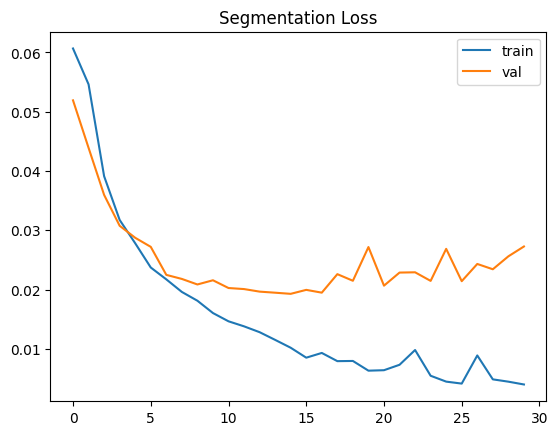

In [96]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Segmentation Loss")
plt.legend(["train","val"])
plt.show()

Predict Tumor Segmentation

1/1 [==============================] - 1s 591ms/step


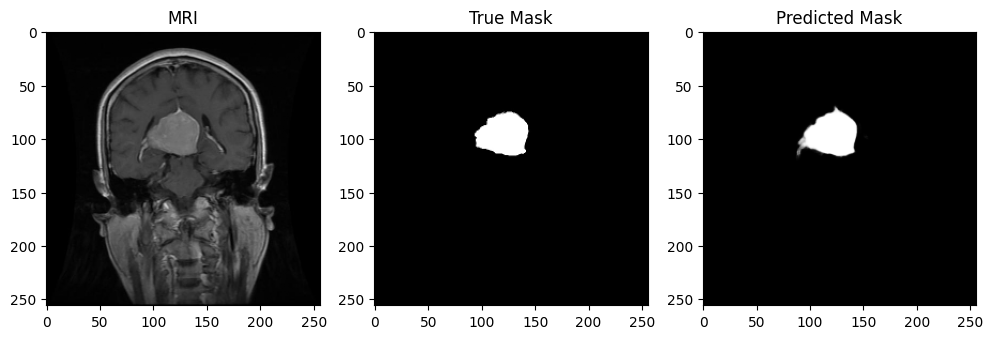

In [97]:
pred = model.predict(X_val[:1])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[0])
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(Y_val[0].squeeze(),cmap='gray')
plt.title("True Mask")

plt.subplot(1,3,3)
plt.imshow(pred[0].squeeze(),cmap='gray')
plt.title("Predicted Mask")

plt.show()

Save Segmentation Model

In [98]:
model.save("model/brain_tumor_unet_segmentation.h5")

## ==============Classification Model Training Part==============

Import Libraries

In [99]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import EfficientNetB0, Xception, MobileNetV2

Dataset Paths

In [103]:
train_dir = "classification_task/train"
test_dir = "classification_task/test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

Data Augmentation

In [104]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

Load Dataset

In [105]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print("Classes:", train_generator.class_indices)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


Model Builder Function

In [106]:
def build_model(base_model):

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Create 3 Models

In [107]:
models = {
    "EfficientNetB0": EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "Xception": Xception(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "MobileNetV2": MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
}

Training Function

In [108]:
histories = {}
trained_models = {}
results = {}

for name, base in models.items():

    print("\nTraining:", name)

    model = build_model(base)

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=50
    )

    histories[name] = history
    trained_models[name] = model


Training: EfficientNetB0
Epoch 1/50
126/126 [==============================] - 183s 1s/step - loss: 1.3960 - accuracy: 0.2694 - val_loss: 1.3807 - val_accuracy: 0.2916
Epoch 2/50
126/126 [==============================] - 109s 862ms/step - loss: 1.3829 - accuracy: 0.2836 - val_loss: 1.3796 - val_accuracy: 0.2916
Epoch 3/50
126/126 [==============================] - 109s 867ms/step - loss: 1.3814 - accuracy: 0.2809 - val_loss: 1.3801 - val_accuracy: 0.2916
Epoch 4/50
126/126 [==============================] - 109s 865ms/step - loss: 1.3826 - accuracy: 0.2866 - val_loss: 1.3794 - val_accuracy: 0.2916
Epoch 5/50
126/126 [==============================] - 110s 873ms/step - loss: 1.3822 - accuracy: 0.2874 - val_loss: 1.3801 - val_accuracy: 0.2916
Epoch 6/50
126/126 [==============================] - 110s 869ms/step - loss: 1.3818 - accuracy: 0.2904 - val_loss: 1.3793 - val_accuracy: 0.2916
Epoch 7/50
126/126 [==============================] - 109s 862ms/step - loss: 1.3811 - accuracy: 0.28

Plot Training Curves

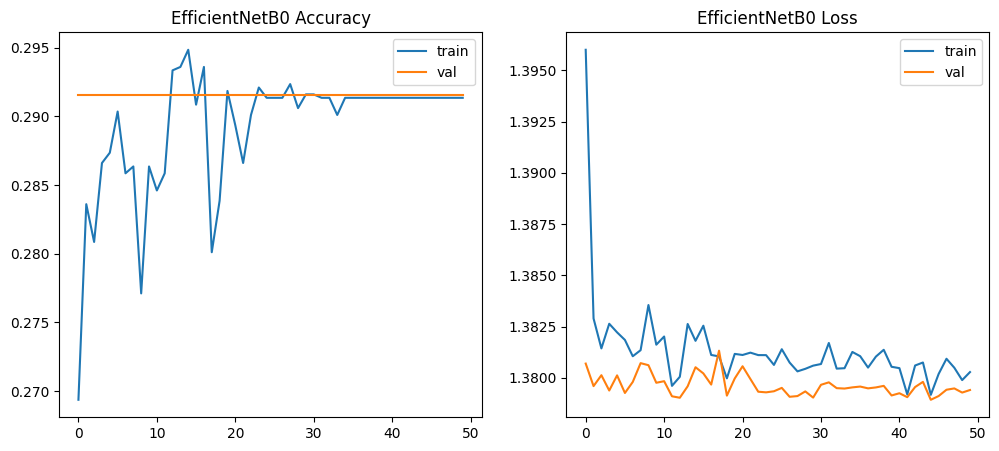

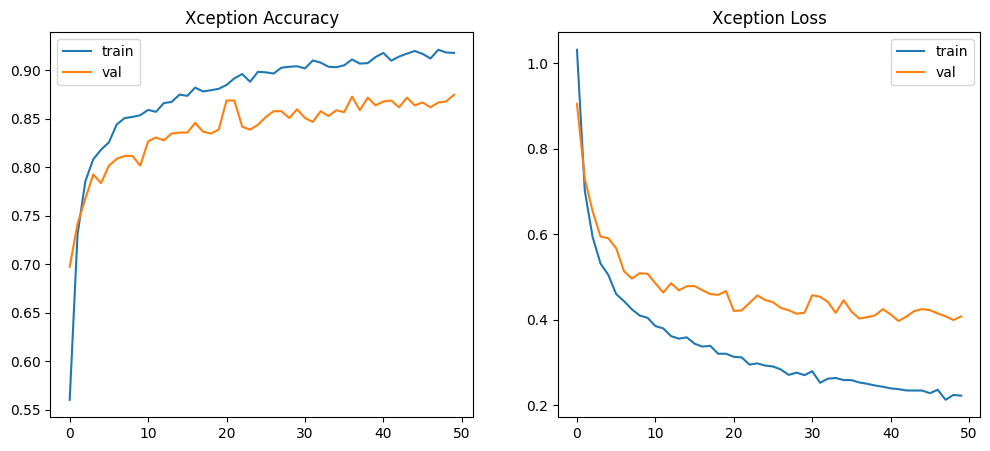

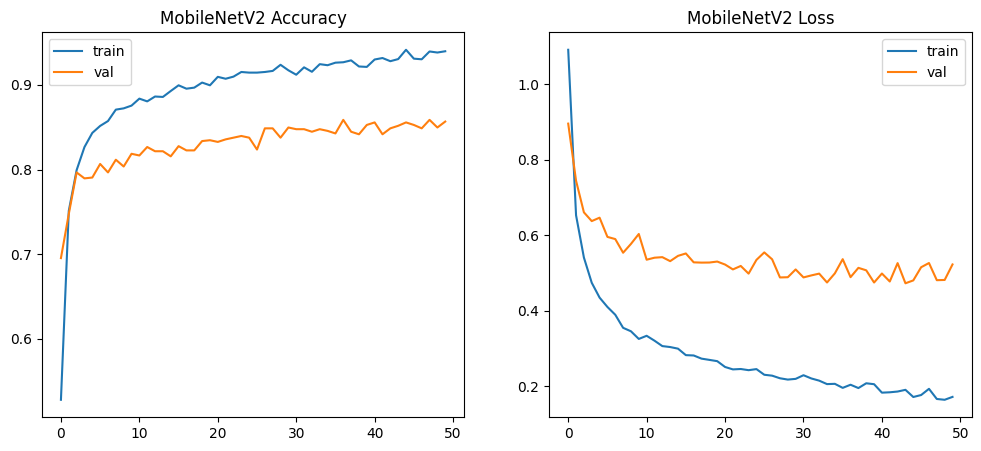

In [109]:
for name, history in histories.items():

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f"{name} Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f"{name} Loss")
    plt.legend()

    plt.show()

Model Evaluation

In [110]:
for name, model in trained_models.items():

    print("\nEvaluating:", name)

    preds = model.predict(test_generator)
    y_pred = np.argmax(preds, axis=1)

    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)

    print("Accuracy:", acc)

    print(classification_report(y_true, y_pred))

    results[name] = acc


Evaluating: EfficientNetB0
32/32 [==============================] - 27s 787ms/step
Accuracy: 0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       254
           1       0.00      0.00      0.00       306
           2       0.00      0.00      0.00       140
           3       0.30      1.00      0.46       300

    accuracy                           0.30      1000
   macro avg       0.07      0.25      0.12      1000
weighted avg       0.09      0.30      0.14      1000


Evaluating: Xception


c:\Users\User\anaconda3\envs\newenv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\User\anaconda3\envs\newenv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\User\anaconda3\envs\newenv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


32/32 [==============================] - 38s 1s/step
Accuracy: 0.847
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       254
           1       0.82      0.68      0.74       306
           2       0.80      0.99      0.89       140
           3       0.85      0.98      0.91       300

    accuracy                           0.85      1000
   macro avg       0.85      0.87      0.85      1000
weighted avg       0.85      0.85      0.84      1000


Evaluating: MobileNetV2
32/32 [==============================] - 14s 421ms/step
Accuracy: 0.814
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       254
           1       0.83      0.59      0.69       306
           2       0.75      0.97      0.85       140
           3       0.77      1.00      0.87       300

    accuracy                           0.81      1000
   macro avg       0.82      0.83      0.81      1000
weighted avg       

Confusion Matrix

32/32 [==============================] - 25s 765ms/step


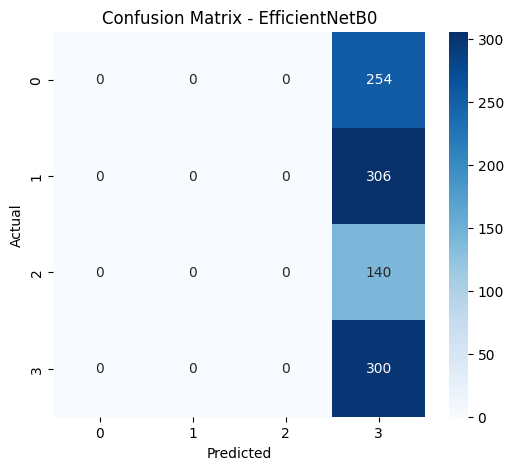

32/32 [==============================] - 39s 1s/step


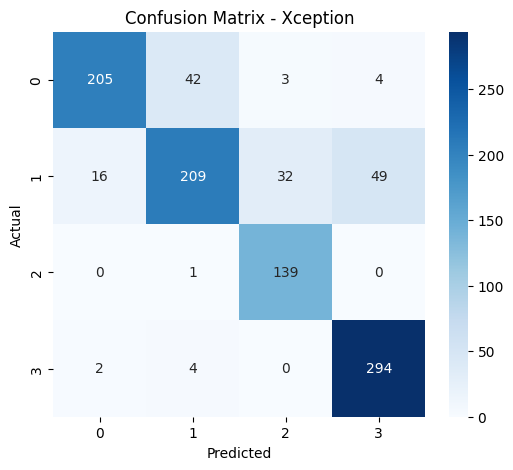

32/32 [==============================] - 13s 415ms/step


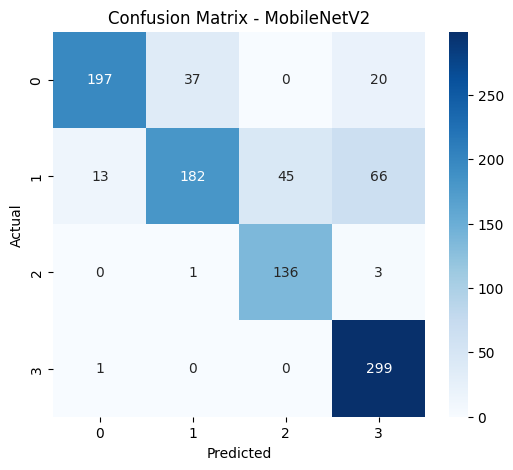

In [111]:
for name, model in trained_models.items():

    preds = model.predict(test_generator)
    y_pred = np.argmax(preds, axis=1)

    cm = confusion_matrix(test_generator.classes, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

Compare Model Accuracy

            Model  Accuracy
0  EfficientNetB0     0.300
1        Xception     0.847
2     MobileNetV2     0.814


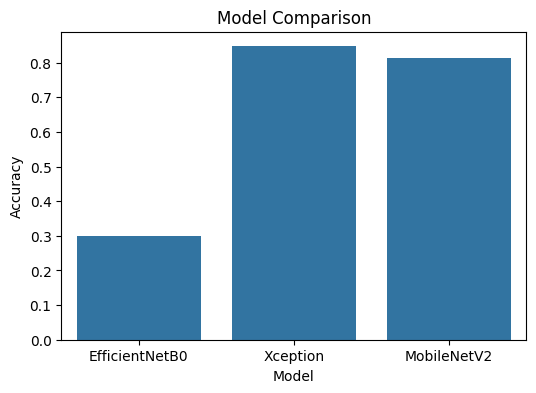

In [112]:
comparison = pd.DataFrame(list(results.items()), columns=["Model","Accuracy"])
print(comparison)

plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=comparison)

plt.title("Model Comparison")
plt.show()

Save Best Model

In [113]:
best_model_name = max(results, key=results.get)

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

best_model.save("model/best_brain_tumor_model.h5")

Best Model: Xception


c:\Users\User\anaconda3\envs\newenv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


================Final Testing================

d:\Anaconda3\envs\myenv\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.8.20). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
d:\Anaconda3\envs\myenv\lib\site-packages\google\auth\__init__.py:52: FutureWarning: You are using a Python version 3.8 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.8"), FutureWarning)
d:\Anaconda3\envs\myenv\lib\site-packages\google\oauth2\__init__.py:38: FutureWarning: You are using a Python version 3.8 past its end of life. Google will update google-auth with critical bug fixes on a best-effort bas

1/1 [==============================] - 1s 721ms/step


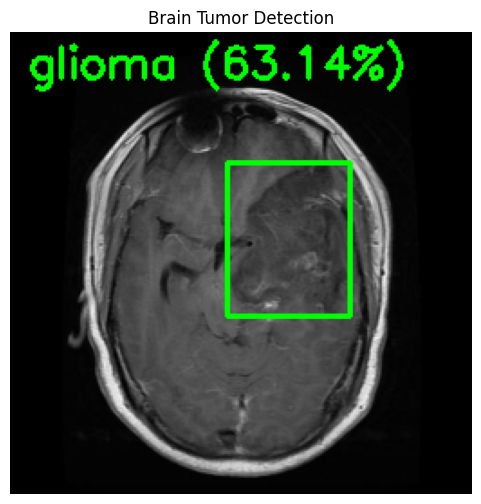

Predicted class: glioma
Confidence: 63.1401002407074 %


In [1]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# LOAD MODELS
# ==============================

class_model = tf.keras.models.load_model("model/best_brain_tumor_model.h5")
seg_model = tf.keras.models.load_model("model/brain_tumor_unet_segmentation.h5")

# class labels
classes = ["glioma","meningioma","pituitary","no_tumor"]

CLASS_SIZE = 224
SEG_SIZE = 256

# ==============================
# IMAGE PATH
# ==============================

img_path = r"C:\Users\User\OneDrive - NSBM\Desktop\Final Project\ML\testing_images_class\glioma\brisc2025_train_00001_gl_ax_t1.jpg"

# ==============================
# LOAD ORIGINAL IMAGE
# ==============================

img = cv2.imread(img_path)
orig = img.copy()

# ==============================
# CLASSIFICATION PREPROCESS
# ==============================

img_class = cv2.resize(img,(CLASS_SIZE,CLASS_SIZE))
img_class = img_class/255.0
img_class = np.expand_dims(img_class,axis=0)

# ==============================
# SEGMENTATION PREPROCESS
# ==============================

img_seg = cv2.resize(img,(SEG_SIZE,SEG_SIZE))
img_seg_norm = img_seg/255.0
img_seg_array = np.expand_dims(img_seg_norm,axis=0)

# ==============================
# CLASSIFICATION
# ==============================

pred = class_model.predict(img_class)

class_id = np.argmax(pred)
predicted_class = classes[class_id]
confidence = float(np.max(pred))*100

# ==============================
# SEGMENTATION (only if tumor)
# ==============================

bbox_img = img_seg.copy()

if predicted_class != "no_tumor":

    seg_pred = seg_model.predict(img_seg_array)

    mask = seg_pred[0,:,:,0]
    mask = (mask > 0.5).astype(np.uint8)

    mask_uint8 = (mask*255).astype(np.uint8)

    contours,_ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:
        x,y,w,h = cv2.boundingRect(cnt)

        cv2.rectangle(
            bbox_img,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )

# ==============================
# ADD TEXT LABEL
# ==============================

label = f"{predicted_class} ({confidence:.2f}%)"

cv2.putText(
    bbox_img,
    label,
    (10,25),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0,255,0),
    2
)

# ==============================
# SHOW RESULT
# ==============================

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(bbox_img,cv2.COLOR_BGR2RGB))
plt.title("Brain Tumor Detection")
plt.axis("off")
plt.show()

print("Predicted class:",predicted_class)
print("Confidence:",confidence,"%")